In [1]:
# Cell 1: Imports & Configuration
import pandas as pd
import numpy as np
import json
import os
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

# Constants
DATA_DIR = 'Manik_Data_For_Romberg/new_data/A_DeviceMotion_data/A_DeviceMotion_data'
SAMPLE_RATE = 50       # Hz
WINDOW_SIZE = 1500     # 30 seconds at 50 Hz
WINDOW_STRIDE = 750    # 15 seconds (50% overlap)
MIN_WINDOW = 750       # minimum 15 seconds to keep a trailing segment

STANDING_TRIALS = ['std_6', 'std_14']
SITTING_TRIALS = ['sit_5', 'sit_13']
NUM_SUBJECTS = 24

print("Configuration ready.")
print(f"  Data dir: {DATA_DIR}")
print(f"  Window: {WINDOW_SIZE} samples ({WINDOW_SIZE/SAMPLE_RATE}s), stride: {WINDOW_STRIDE} ({WINDOW_STRIDE/SAMPLE_RATE}s)")

Configuration ready.
  Data dir: Manik_Data_For_Romberg/new_data/A_DeviceMotion_data/A_DeviceMotion_data
  Window: 1500 samples (30.0s), stride: 750 (15.0s)


## 1. Load the MotionSense Dataset

Load all CSVs from the standing (std_6, std_14) and sitting (sit_5, sit_13) trial folders. Each folder has 24 subject files.

In [2]:
# Cell 2: Load Data
raw_data = []

for trial in STANDING_TRIALS + SITTING_TRIALS:
    label = 'standing' if trial.startswith('std') else 'sitting'
    trial_dir = os.path.join(DATA_DIR, trial)
    for subj in range(1, NUM_SUBJECTS + 1):
        fpath = os.path.join(trial_dir, f'sub_{subj}.csv')
        if not os.path.exists(fpath):
            print(f"  MISSING: {fpath}")
            continue
        df = pd.read_csv(fpath)
        raw_data.append({
            'subject': subj,
            'trial': trial,
            'label': label,
            'df': df
        })

print(f"Loaded {len(raw_data)} files")
print(f"  Standing: {sum(1 for d in raw_data if d['label']=='standing')}")
print(f"  Sitting:  {sum(1 for d in raw_data if d['label']=='sitting')}")

# Show a sample
sample = raw_data[0]
print(f"\nSample file: {sample['trial']}/sub_{sample['subject']}.csv")
print(f"  Shape: {sample['df'].shape}")
print(f"  Duration: {len(sample['df'])/SAMPLE_RATE:.1f}s")
print(f"  Columns: {list(sample['df'].columns)}")
sample['df'].head(3)

Loaded 96 files
  Standing: 48
  Sitting:  48

Sample file: std_6/sub_1.csv
  Shape: (10194, 13)
  Duration: 203.9s
  Columns: ['Unnamed: 0', 'attitude.roll', 'attitude.pitch', 'attitude.yaw', 'gravity.x', 'gravity.y', 'gravity.z', 'rotationRate.x', 'rotationRate.y', 'rotationRate.z', 'userAcceleration.x', 'userAcceleration.y', 'userAcceleration.z']


,Unnamed: 0,attitude.roll,attitude.pitch,attitude.yaw,gravity.x,gravity.y,gravity.z,rotationRate.x,rotationRate.y,rotationRate.z,userAcceleration.x,userAcceleration.y,userAcceleration.z
0,0,2.489271,-1.397067,1.899690,0.104929,0.984947,0.137365,-0.060667,-0.333742,-0.008674,0.007192,-0.004249,0.065989
1,1,2.488154,-1.396068,1.905025,0.105682,0.984774,0.138030,-0.073340,-0.302813,-0.006666,-0.082061,0.004820,0.022905
2,2,2.489687,-1.394939,1.912298,0.106144,0.984577,0.139074,-0.090184,-0.270723,-0.024985,-0.101612,0.008953,0.002664


## 2. Feature Extraction

Segment each file into 30-second windows (1500 samples at 50Hz) with 50% overlap. Extract 8 features per window from `userAcceleration.x/y/z`. These same features will be computed in the website's JavaScript.

In [3]:
# Cell 3: Feature Extraction

def extract_features(ax, ay, az, sample_rate=50):
    """Extract 8 features from acceleration arrays. Mirrors the JS extractFeatures() exactly."""
    n = len(ax)
    if n < 10:
        return None
    
    # Magnitude
    mag = np.sqrt(ax**2 + ay**2 + az**2)
    
    # Jerk (frame-to-frame difference scaled by sample rate)
    dx = np.diff(ax)
    dy = np.diff(ay)
    dz = np.diff(az)
    jerk = np.sqrt(dx**2 + dy**2 + dz**2) * sample_rate
    
    # Path length (sum of inter-frame displacements, normalized by count)
    displacements = np.sqrt(dx**2 + dy**2 + dz**2)
    path_length = np.sum(displacements) / n
    
    return {
        'rms_sway': np.sqrt(np.mean(mag**2)),
        'std_x': np.std(ax, ddof=0),  # population std (matches JS)
        'std_y': np.std(ay, ddof=0),
        'std_z': np.std(az, ddof=0),
        'mean_jerk': np.mean(jerk),
        'path_length': path_length,
        'sway_mean': np.mean(mag),
        'sway_peak': np.max(mag),
    }

def segment_and_extract(df, window_size=WINDOW_SIZE, stride=WINDOW_STRIDE, 
                         min_window=MIN_WINDOW, sample_rate=SAMPLE_RATE):
    """Window a dataframe and extract features from each window."""
    ax = df['userAcceleration.x'].values
    ay = df['userAcceleration.y'].values
    az = df['userAcceleration.z'].values
    
    n = len(ax)
    windows = []
    start = 0
    while start + min_window <= n:
        end = min(start + window_size, n)
        feats = extract_features(ax[start:end], ay[start:end], az[start:end], sample_rate)
        if feats is not None:
            feats['window_start'] = start
            feats['window_samples'] = end - start
            windows.append(feats)
        start += stride
    return windows

# Build the feature matrix
rows = []
for entry in raw_data:
    windows = segment_and_extract(entry['df'])
    for w in windows:
        w['subject'] = entry['subject']
        w['trial'] = entry['trial']
        w['label'] = entry['label']
        rows.append(w)

feature_df = pd.DataFrame(rows)
FEATURE_NAMES = ['rms_sway', 'std_x', 'std_y', 'std_z', 'mean_jerk', 'path_length', 'sway_mean', 'sway_peak']

print(f"Feature matrix: {feature_df.shape}")
print(f"\nClass distribution:")
print(feature_df['label'].value_counts())
print(f"\nWindows per subject:")
print(feature_df.groupby('subject').size().describe())
print(f"\nWindows per trial:")
print(feature_df.groupby('trial').size())
feature_df[FEATURE_NAMES + ['label']].describe()

Feature matrix: (812, 13)

Class distribution:
label
sitting     426
standing    386
Name: count, dtype: int64

Windows per subject:
count    24.000000
mean     33.833333
std       5.087638
min      23.000000
25%      31.000000
50%      34.500000
75%      36.000000
max      47.000000
dtype: float64

Windows per trial:
trial
sit_13    125
sit_5     301
std_14     97
std_6     289
dtype: int64


,rms_sway,std_x,std_y,std_z,mean_jerk,path_length,sway_mean,sway_peak
count,812.000000,812.000000,812.000000,812.000000,812.000000,812.000000,812.000000,812.000000
mean,0.040625,0.015762,0.011777,0.013879,0.471279,0.009419,0.035543,0.198728
std,0.029393,0.011423,0.008624,0.010220,0.276672,0.005529,0.028381,0.208901
min,0.004646,0.001410,0.001316,0.001475,0.128983,0.002578,0.004336,0.010853
25%,0.020129,0.007506,0.006066,0.005833,0.263037,0.005256,0.016685,0.075710
50%,0.032591,0.012488,0.009597,0.011904,0.398433,0.007963,0.027024,0.148429
75%,0.052911,0.021242,0.014718,0.018361,0.613242,0.012257,0.045264,0.244481
max,0.212807,0.075123,0.081324,0.065346,2.531190,0.050588,0.212071,1.858783


## 3. Exploratory Data Analysis

Visualize feature distributions and class separability.

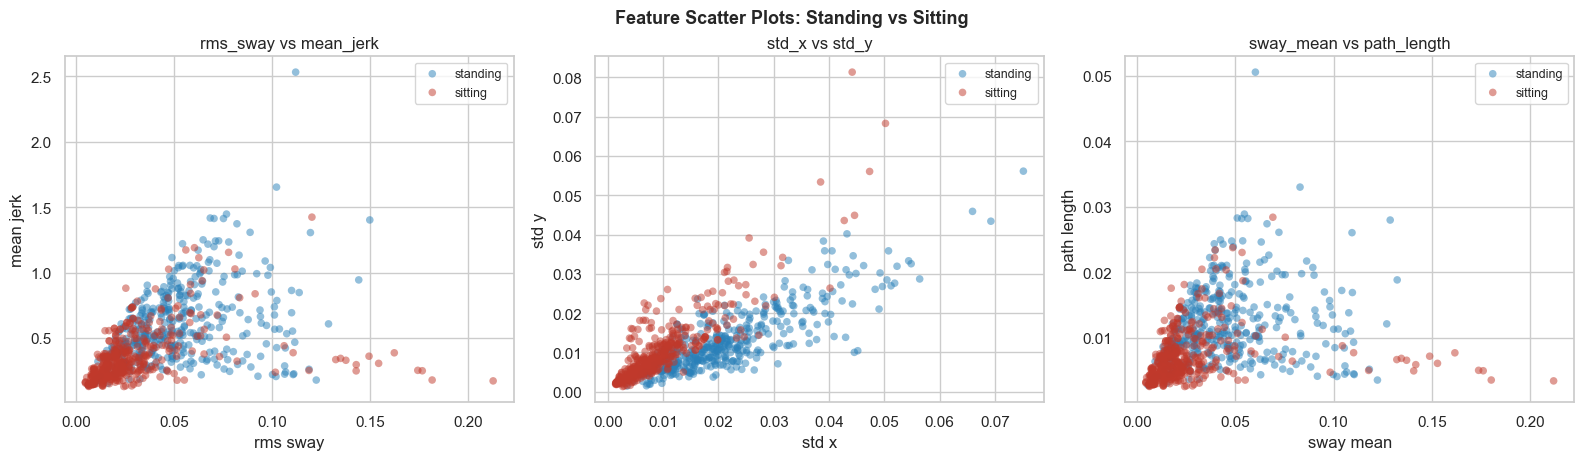

In [4]:
# Cell 4: EDA — Scatter plots of key feature pairs
colors = {'standing': '#2980b9', 'sitting': '#c0392b'}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

pairs = [('rms_sway', 'mean_jerk'), ('std_x', 'std_y'), ('sway_mean', 'path_length')]
for ax, (fx, fy) in zip(axes, pairs):
    for label, color in colors.items():
        mask = feature_df['label'] == label
        ax.scatter(feature_df.loc[mask, fx], feature_df.loc[mask, fy],
                   alpha=0.5, s=30, c=color, label=label, edgecolors='none')
    ax.set_xlabel(fx.replace('_', ' '))
    ax.set_ylabel(fy.replace('_', ' '))
    ax.legend(frameon=True, fontsize=9)
    ax.set_title(f'{fx} vs {fy}')

plt.tight_layout()
plt.suptitle('Feature Scatter Plots: Standing vs Sitting', y=1.02, fontsize=13, fontweight='bold')
plt.show()

/var/folders/by/cy0ym4p133zfzvfnyhvjydx40000gn/T/ipykernel_90473/3498607877.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=feature_df, x='label', y=feat, ax=ax, palette=colors, width=0.5)
/var/folders/by/cy0ym4p133zfzvfnyhvjydx40000gn/T/ipykernel_90473/3498607877.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=feature_df, x='label', y=feat, ax=ax, palette=colors, width=0.5)
/var/folders/by/cy0ym4p133zfzvfnyhvjydx40000gn/T/ipykernel_90473/3498607877.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=feature_df, x='lab

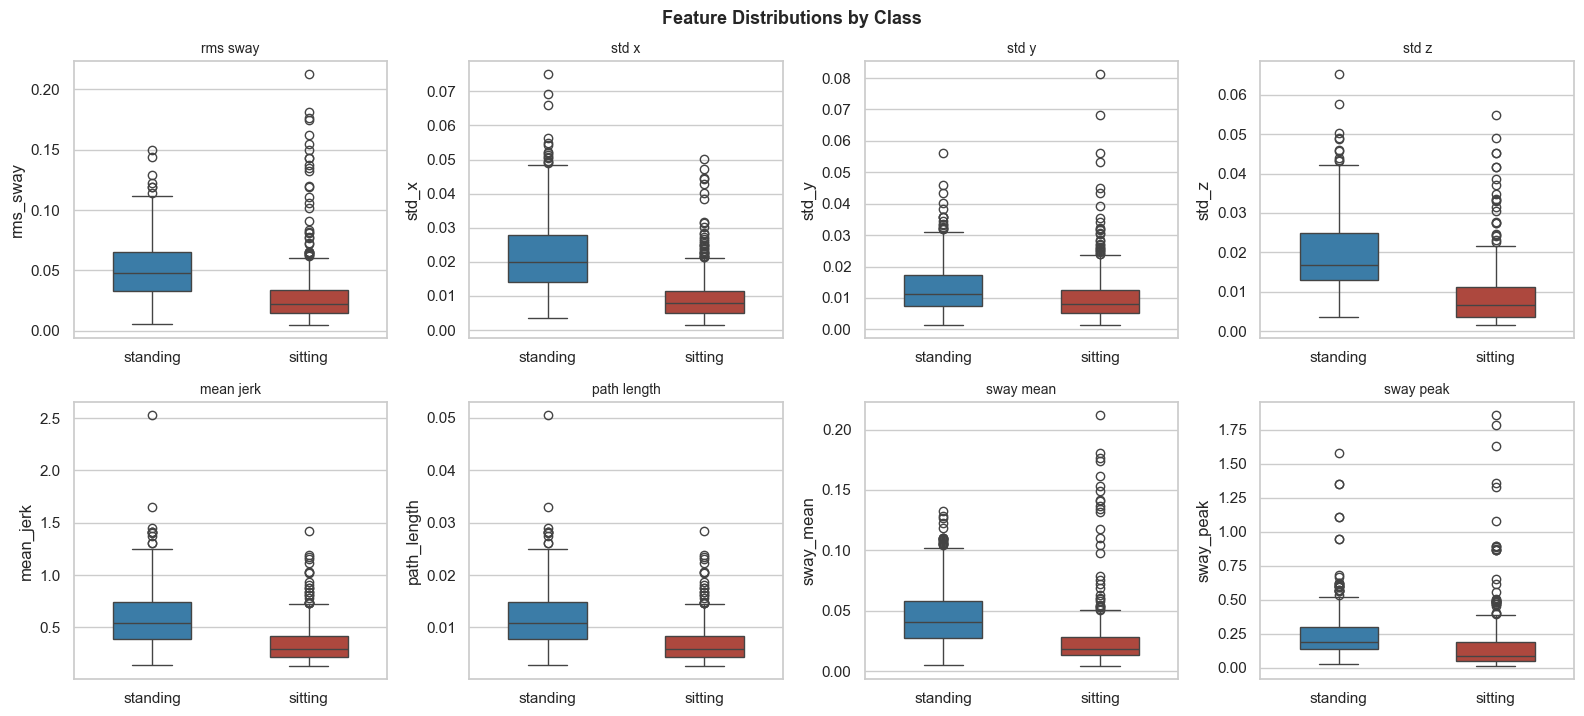

In [5]:
# Cell 5: EDA — Box plots per feature by class
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, feat in zip(axes.flat, FEATURE_NAMES):
    sns.boxplot(data=feature_df, x='label', y=feat, ax=ax, palette=colors, width=0.5)
    ax.set_title(feat.replace('_', ' '), fontsize=10)
    ax.set_xlabel('')

plt.tight_layout()
plt.suptitle('Feature Distributions by Class', y=1.02, fontsize=13, fontweight='bold')
plt.show()

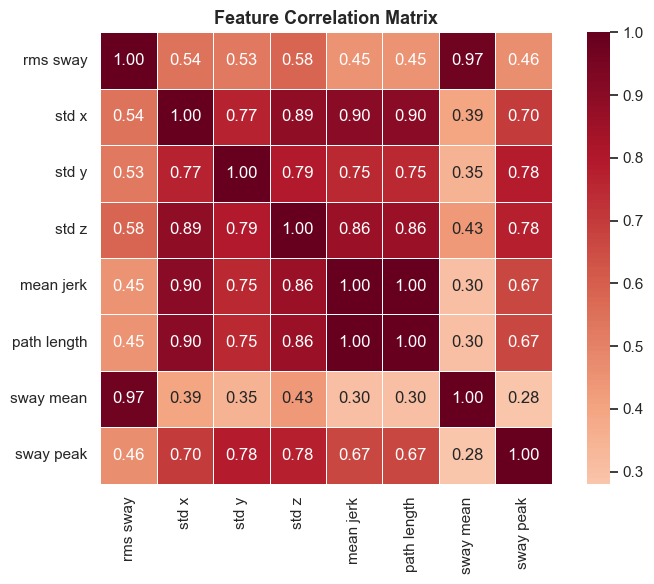

In [6]:
# Cell 6: EDA — Correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
corr = feature_df[FEATURE_NAMES].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            square=True, ax=ax, linewidths=0.5,
            xticklabels=[f.replace('_', ' ') for f in FEATURE_NAMES],
            yticklabels=[f.replace('_', ' ') for f in FEATURE_NAMES])
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Model Training — Leave-One-Subject-Out Cross-Validation

We use `LeaveOneGroupOut` grouped by subject so the model never sees data from the test subject during training. This prevents data leakage from overlapping windows of the same person.

In [7]:
# Cell 7: Leave-One-Subject-Out Cross-Validation
X = feature_df[FEATURE_NAMES].values
y = feature_df['label'].values
groups = feature_df['subject'].values

logo = LeaveOneGroupOut()
y_pred_all = np.empty_like(y, dtype=object)
per_subject_results = []

for train_idx, test_idx in logo.split(X, y, groups):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    clf = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=42)
    clf.fit(X_train_s, y_train)
    
    y_pred = clf.predict(X_test_s)
    y_pred_all[test_idx] = y_pred
    
    subj = groups[test_idx[0]]
    acc = accuracy_score(y_test, y_pred)
    per_subject_results.append({'subject': subj, 'accuracy': acc, 'n_samples': len(y_test)})

# Overall metrics
overall_acc = accuracy_score(y, y_pred_all)
print(f"=== Leave-One-Subject-Out Cross-Validation ===")
print(f"Overall Accuracy: {overall_acc:.4f} ({overall_acc*100:.1f}%)\n")
print(classification_report(y, y_pred_all, target_names=['sitting', 'standing']))

=== Leave-One-Subject-Out Cross-Validation ===
Overall Accuracy: 0.9150 (91.5%)

              precision    recall  f1-score   support

     sitting       0.91      0.92      0.92       426
    standing       0.92      0.90      0.91       386

    accuracy                           0.92       812
   macro avg       0.92      0.91      0.91       812
weighted avg       0.92      0.92      0.91       812



## 5. Evaluation Visualizations

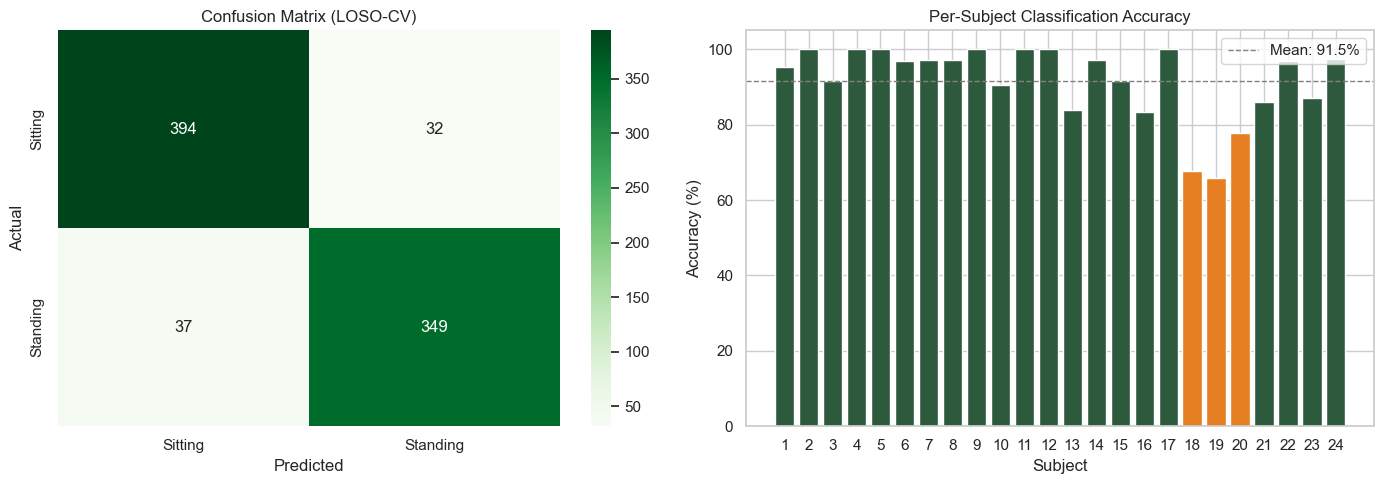


Per-subject accuracy summary:
  Mean: 91.8%
  Min:  66.0% (Subject 19)
  Max:  100.0%


In [8]:
# Cell 8: Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y, y_pred_all, labels=['sitting', 'standing'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Sitting', 'Standing'], yticklabels=['Sitting', 'Standing'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix (LOSO-CV)')

# Per-subject accuracy
subj_df = pd.DataFrame(per_subject_results).sort_values('subject')
bar_colors = ['#2d5a3d' if a >= 0.8 else '#e67e22' if a >= 0.5 else '#c0392b' 
              for a in subj_df['accuracy']]
axes[1].bar(subj_df['subject'].astype(str), subj_df['accuracy'] * 100, color=bar_colors)
axes[1].set_xlabel('Subject')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Per-Subject Classification Accuracy')
axes[1].axhline(y=overall_acc * 100, color='gray', linestyle='--', linewidth=1, label=f'Mean: {overall_acc*100:.1f}%')
axes[1].legend()
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.show()

print(f"\nPer-subject accuracy summary:")
print(f"  Mean: {subj_df['accuracy'].mean()*100:.1f}%")
print(f"  Min:  {subj_df['accuracy'].min()*100:.1f}% (Subject {subj_df.loc[subj_df['accuracy'].idxmin(), 'subject']})")
print(f"  Max:  {subj_df['accuracy'].max()*100:.1f}%")

## 6. Train Final Model & Export Weights

Train on the full dataset and export the model parameters (scaler mean/std, logistic regression weights/bias) as JSON for the website.

Final model classes: ['sitting', 'standing']
Final model intercept: 0.5131258283

Feature weights:
  rms_sway       : -0.8980637264
  std_x          : +4.8349908570
  std_y          : -3.3728412486
  std_z          : +3.1769723615
  mean_jerk      : -0.5154483557
  path_length    : -0.5154772482
  sway_mean      : +1.3270658877
  sway_peak      : -1.7949453535


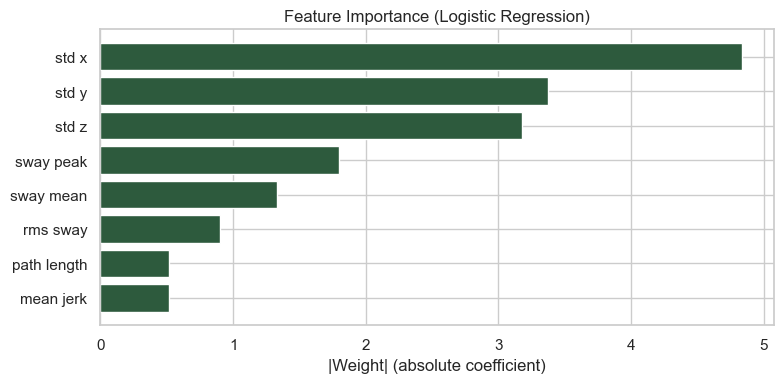

In [9]:
# Cell 9: Train final model on ALL data
final_scaler = StandardScaler()
X_scaled = final_scaler.fit_transform(X)

final_model = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=42)
final_model.fit(X_scaled, y)

print(f"Final model classes: {list(final_model.classes_)}")
print(f"Final model intercept: {final_model.intercept_[0]:.10f}")
print(f"\nFeature weights:")
for name, weight in zip(FEATURE_NAMES, final_model.coef_[0]):
    print(f"  {name:15s}: {weight:+.10f}")

# Feature importance plot
fig, ax = plt.subplots(figsize=(8, 4))
importance = np.abs(final_model.coef_[0])
sorted_idx = np.argsort(importance)
ax.barh([FEATURE_NAMES[i].replace('_', ' ') for i in sorted_idx], importance[sorted_idx], color='#2d5a3d')
ax.set_xlabel('|Weight| (absolute coefficient)')
ax.set_title('Feature Importance (Logistic Regression)')
plt.tight_layout()
plt.show()

In [10]:
# Cell 10: Export model weights as JSON

# Compute CV metrics for embedding in website
precision_per_class = precision_score(y, y_pred_all, labels=['sitting', 'standing'], average=None)
recall_per_class = recall_score(y, y_pred_all, labels=['sitting', 'standing'], average=None)
f1_per_class = f1_score(y, y_pred_all, labels=['sitting', 'standing'], average=None)
cm_list = confusion_matrix(y, y_pred_all, labels=['sitting', 'standing']).tolist()

# Per-subject accuracy for embedding
per_subj_export = [{'subject': int(r['subject']), 'accuracy': round(r['accuracy'], 4)} 
                   for r in per_subject_results]

model_export = {
    'model_type': 'logistic_regression',
    'feature_names': FEATURE_NAMES,
    'scaler_mean': final_scaler.mean_.tolist(),
    'scaler_std': final_scaler.scale_.tolist(),
    'weights': final_model.coef_[0].tolist(),
    'bias': float(final_model.intercept_[0]),
    'classes': list(final_model.classes_),  # ['sitting', 'standing']
    'cv_accuracy': round(overall_acc, 4),
    'cv_metrics': {
        'precision': {'sitting': round(precision_per_class[0], 4), 'standing': round(precision_per_class[1], 4)},
        'recall': {'sitting': round(recall_per_class[0], 4), 'standing': round(recall_per_class[1], 4)},
        'f1': {'sitting': round(f1_per_class[0], 4), 'standing': round(f1_per_class[1], 4)},
        'confusion_matrix': cm_list,
    },
    'per_subject_accuracy': per_subj_export,
    'dataset_info': {
        'n_subjects': int(len(set(groups))),
        'n_windows': int(len(y)),
        'n_standing': int(np.sum(y == 'standing')),
        'n_sitting': int(np.sum(y == 'sitting')),
        'window_size_sec': WINDOW_SIZE / SAMPLE_RATE,
        'sample_rate_hz': SAMPLE_RATE,
    }
}

# Save to file
with open('model_weights.json', 'w') as f:
    json.dump(model_export, f, indent=2)

print("Model exported to model_weights.json")
print(f"\nExport summary:")
print(f"  Classes: {model_export['classes']}")
print(f"  Weights: {len(model_export['weights'])} features")
print(f"  CV Accuracy: {model_export['cv_accuracy']}")
print(f"  Dataset: {model_export['dataset_info']['n_windows']} windows from {model_export['dataset_info']['n_subjects']} subjects")

Model exported to model_weights.json

Export summary:
  Classes: ['sitting', 'standing']
  Weights: 8 features
  CV Accuracy: 0.915
  Dataset: 812 windows from 24 subjects


## 7. Verification

Re-implement prediction in pure numpy to verify the exported weights produce the same results as sklearn.

In [ ]:
# Cell 11: Verify exported model matches sklearn predictions

with open('model_weights.json', 'r') as f:
    loaded = json.load(f)

w = np.array(loaded['weights'])
b = loaded['bias']
mu = np.array(loaded['scaler_mean'])
sigma = np.array(loaded['scaler_std'])
classes = loaded['classes']

def predict_from_json(feature_dict):
    """Predict using exported JSON weights — same logic the website will use."""
    x = np.array([feature_dict[f] for f in loaded['feature_names']])
    x_scaled = (x - mu) / sigma
    z = np.dot(w, x_scaled) + b
    prob = 1 / (1 + np.exp(-z))
    # classes[0] = 'sitting', classes[1] = 'standing'
    # sklearn: positive class is classes[1] ('standing') when prob > 0.5
    label = classes[1] if prob > 0.5 else classes[0]
    return label, prob

# Test on 20 random samples
np.random.seed(42)
test_indices = np.random.choice(len(feature_df), 20, replace=False)
mismatches = 0

for idx in test_indices:
    row = feature_df.iloc[idx]
    feat_dict = {f: row[f] for f in FEATURE_NAMES}
    json_label, json_prob = predict_from_json(feat_dict)
    
    # sklearn prediction
    x_sklearn = final_scaler.transform([X[idx]])
    sklearn_label = final_model.predict(x_sklearn)[0]
    sklearn_prob = final_model.predict_proba(x_sklearn)[0][1]  # prob of 'standing'
    
    match = json_label == sklearn_label
    if not match:
        mismatches += 1
        print(f"  MISMATCH at idx {idx}: JSON={json_label} ({json_prob:.4f}), sklearn={sklearn_label} ({sklearn_prob:.4f})")

print(f"\nVerification: {20 - mismatches}/20 predictions match between JSON export and sklearn.")
if mismatches == 0:
    print("All predictions match — export is correct.")


Verification: 20/20 predictions match between JSON export and sklearn.
All predictions match — export is correct.


# Romberger: Standing vs Sitting Classifier

Train a logistic regression model on the MotionSense dataset to classify **standing** vs **sitting** from smartphone accelerometer data. The trained model weights are exported as JSON for use in the Romberger web app.